In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

REQUIRED_DATA_FILES = {
    "train_demos.pkl",
    "valid_scenarios.pkl",
    "test_scenarios.pkl",
}


def contains_required_files(folder: Path) -> bool:
    return folder.is_dir() and REQUIRED_DATA_FILES.issubset(
        {path.name for path in folder.iterdir() if path.is_file()}
    )


def find_data_directory() -> Path | None:
    candidates = [
        Path("/kaggle/input/competitions/ioai-2026-home-task-2"),
        Path("/kaggle/input/ioai-2026-home-task-2"),
        Path("/content/data"),
        Path("data"),
    ]

    for candidate in candidates:
        if contains_required_files(candidate):
            return candidate

    # Kaggle puede montar la competencia bajo una carpeta con nombre ligeramente distinto.
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.is_dir():
        for train_file in kaggle_root.rglob("train_demos.pkl"):
            if contains_required_files(train_file.parent):
                return train_file.parent

    return None


DATA_DIR = find_data_directory()

if DATA_DIR is None:
    if importlib.util.find_spec("gdown") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])

    import gdown

    download_dir = Path("data")
    download_dir.mkdir(parents=True, exist_ok=True)

    print("No se encontraron los datos localmente. Descargando la carpeta pública...")
    gdown.download_folder(
        id="1DXFDoY9bqulMBFacyDShVIx8Sa7Z5Wpa",
        output=str(download_dir),
        quiet=False,
        use_cookies=False,
    )
    DATA_DIR = find_data_directory()

if DATA_DIR is None:
    raise FileNotFoundError(
        "No fue posible encontrar train_demos.pkl, valid_scenarios.pkl y "
        "test_scenarios.pkl. En Kaggle, agregue los datos de la competencia "
        "al notebook; en Colab, habilite internet para la descarga pública."
    )

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("Archivos:", sorted(path.name for path in DATA_DIR.iterdir()))

DATA_DIR: /kaggle/input/competitions/ioai-2026-home-task-2
OUTPUT_DIR: /kaggle/working
Archivos: ['test_scenarios.pkl', 'train_demos.pkl', 'valid_scenarios.pkl']


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [3]:
import json
import pickle
import random
import zipfile
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from IPython.display import Image as NotebookImage, display
from PIL import Image as PILImage, ImageDraw
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

GRID_SIZE = 8
N_DEPOTS = 6
MAX_STEPS = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACTION_NAMES = {
    0: "south",
    1: "north",
    2: "east",
    3: "west",
    4: "pickup",
    5: "dropoff",
}

ACTION_DELTAS = {
    0: (1, 0),
    1: (-1, 0),
    2: (0, 1),
    3: (0, -1),
}

DEPOT_NAMES = ["A", "B", "C", "D", "E", "F"]

print("data dir:", DATA_DIR)
print("device:", DEVICE)

data dir: /kaggle/input/competitions/ioai-2026-home-task-2
device: cuda


In [4]:
class DeliverySimulator8x8:
    """Run one 8x8 delivery episode."""

    def reset(self, scenario: dict[str, Any]) -> tuple[int, int, int, int]:
        """Start a scenario and return the compact state."""
        self.step_count = 0
        self.carrying = False
        self.walls = {tuple(cell) for cell in scenario["walls"]}
        self.depots = [tuple(cell) for cell in scenario["depots"]]
        self.agent_pos = tuple(scenario["agent_pos"])
        self.package_location = int(scenario["package_location"])
        self.destination = int(scenario["destination"])
        return self.state()

    def state(self) -> tuple[int, int, int, int]:
        """Return row, column, package field, and destination."""
        package_field = N_DEPOTS if self.carrying else self.package_location
        return int(self.agent_pos[0]), int(self.agent_pos[1]), int(package_field), int(self.destination)

    def can_enter(self, row: int, col: int) -> bool:
        """Check whether the robot can occupy a cell."""
        return 0 <= row < GRID_SIZE and 0 <= col < GRID_SIZE and (row, col) not in self.walls

    def valid_action_mask(self) -> np.ndarray:
        """Return the currently valid actions."""
        row, col, _, destination = self.state()
        mask = np.zeros(6, dtype=bool)
        for action, (dr, dc) in ACTION_DELTAS.items():
            mask[action] = self.can_enter(row + dr, col + dc)
        mask[4] = (not self.carrying) and self.agent_pos == self.depots[self.package_location]
        mask[5] = self.carrying and self.agent_pos == self.depots[destination]
        return mask

    def observation(self) -> dict[str, Any]:
        """Build the model observation for the current state."""
        row, col, package_field, destination = self.state()
        carrying = package_field == N_DEPOTS
        dest_row, dest_col = self.depots[destination]
        target_row, target_col = (dest_row, dest_col) if carrying else self.depots[package_field]

        grid = np.zeros((6, GRID_SIZE, GRID_SIZE), dtype=np.float32)
        for wr, wc in self.walls:
            grid[0, wr, wc] = 1.0
        for dr, dc in self.depots:
            grid[1, dr, dc] = 1.0
        grid[2, row, col] = 1.0
        if not carrying:
            pr, pc = self.depots[package_field]
            grid[3, pr, pc] = 1.0
        grid[4, dest_row, dest_col] = 1.0
        grid[5, :, :] = float(carrying)

        blocked_moves = [float(not self.can_enter(row + dr, col + dc)) for dr, dc in ACTION_DELTAS.values()]
        vector = np.array(
            [
                row / (GRID_SIZE - 1),
                col / (GRID_SIZE - 1),
                package_field / N_DEPOTS,
                destination / (N_DEPOTS - 1),
                float(carrying),
                target_row / (GRID_SIZE - 1),
                target_col / (GRID_SIZE - 1),
                (target_row - row) / (GRID_SIZE - 1),
                (target_col - col) / (GRID_SIZE - 1),
                *blocked_moves,
            ],
            dtype=np.float32,
        )
        return {"grid": grid, "vector": vector, "action_mask": self.valid_action_mask(), "state": self.state()}

    def step(self, action: int) -> tuple[tuple[int, int, int, int], bool, bool, dict[str, Any]]:
        """Apply one action and report episode status."""
        action = int(action)
        done = False
        info = {"invalid_pickup_or_dropoff": False}

        if action in ACTION_DELTAS:
            dr, dc = ACTION_DELTAS[action]
            row, col = self.agent_pos[0] + dr, self.agent_pos[1] + dc
            if self.can_enter(row, col):
                self.agent_pos = (row, col)
        elif action == 4 and (not self.carrying) and self.agent_pos == self.depots[self.package_location]:
            self.carrying = True
        elif action == 5 and self.carrying and self.agent_pos == self.depots[self.destination]:
            done = True
            self.carrying = False
            self.package_location = self.destination
        elif action in (4, 5):
            info["invalid_pickup_or_dropoff"] = True
        else:
            raise ValueError(f"unknown action: {action}")

        self.step_count += 1
        return self.state(), done, self.step_count >= MAX_STEPS and not done, info

    def render(self) -> str:
        """Return an ASCII rendering of the current grid."""
        grid = [["." for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
        for row, col in self.walls:
            grid[row][col] = "#"
        for i, (row, col) in enumerate(self.depots):
            grid[row][col] = DEPOT_NAMES[i]

        agent_row, agent_col = self.agent_pos
        grid[agent_row][agent_col] = "T*" if self.carrying else "T"
        rows = [" ".join(f"{cell:>2}" for cell in row) for row in grid]
        package_name = "in taxi" if self.carrying else DEPOT_NAMES[self.package_location]
        rows.append(f"package={package_name}, destination={DEPOT_NAMES[self.destination]}")
        return "\n".join(rows)

In [5]:
CELL_SIZE = 56
FRAME_FOOTER = 44
DEPOT_COLORS = ["#ef4444", "#3b82f6", "#22c55e", "#f59e0b", "#a855f7", "#06b6d4"]


def draw_episode_frame(simulator, step=0, action_name="start"):
    """Render the current simulator state as a PIL image."""
    width = GRID_SIZE * CELL_SIZE
    height = GRID_SIZE * CELL_SIZE + FRAME_FOOTER
    image = PILImage.new("RGB", (width, height), "#f8fafc")
    draw = ImageDraw.Draw(image)

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            x0, y0 = col * CELL_SIZE, row * CELL_SIZE
            x1, y1 = x0 + CELL_SIZE, y0 + CELL_SIZE
            fill = "#334155" if (row, col) in simulator.walls else "#f8fafc"
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline="#cbd5e1")

    target_id = simulator.destination if simulator.carrying else simulator.package_location
    for depot_id, (row, col) in enumerate(simulator.depots):
        x0, y0 = col * CELL_SIZE + 8, row * CELL_SIZE + 8
        x1, y1 = x0 + CELL_SIZE - 16, y0 + CELL_SIZE - 16
        color = DEPOT_COLORS[depot_id]
        draw.rounded_rectangle([x0, y0, x1, y1], radius=10, fill=color)
        draw.text((x0 + 14, y0 + 9), DEPOT_NAMES[depot_id], fill="white")
        if depot_id == target_id:
            draw.rounded_rectangle([x0 - 4, y0 - 4, x1 + 4, y1 + 4], radius=14, outline="#111827", width=4)

    row, col = simulator.agent_pos
    cx, cy = col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2
    draw.ellipse([cx - 18, cy - 18, cx + 18, cy + 18], fill="#111827")
    draw.text((cx - 5, cy - 8), "T", fill="white")
    if simulator.carrying:
        draw.rectangle([cx + 10, cy - 24, cx + 25, cy - 9], fill="#f97316", outline="#9a3412")

    package = "in robot" if simulator.carrying else DEPOT_NAMES[simulator.package_location]
    footer = f"step {step:02d} | action: {action_name} | package: {package} -> {DEPOT_NAMES[simulator.destination]}"
    draw.rectangle([0, GRID_SIZE * CELL_SIZE, width, height], fill="#e2e8f0")
    draw.text((12, GRID_SIZE * CELL_SIZE + 14), footer, fill="#0f172a")
    return image


def show_episode_gif(scenario, actions, path="episode.gif", duration=450):
    """Save and display an animated GIF for one action sequence."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames = [draw_episode_frame(simulator)]
    for step, action in enumerate(actions, start=1):
        simulator.step(action)
        frames.append(draw_episode_frame(simulator, step, ACTION_NAMES[action]))
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    display(NotebookImage(filename=path))

In [6]:
with (DATA_DIR / "train_demos.pkl").open("rb") as f:
    train_data = pickle.load(f)
with (DATA_DIR / "valid_scenarios.pkl").open("rb") as f:
    valid_scenarios = pickle.load(f)
with (DATA_DIR / "test_scenarios.pkl").open("rb") as f:
    test_scenarios = pickle.load(f)

train_trajectories = train_data["trajectories"]
steps = [t["num_steps"] for t in train_trajectories]

print("Loaded data")
print("  training demonstrations:", len(train_trajectories))
print("  validation scenarios:", len(valid_scenarios))
print("  test scenarios:", len(test_scenarios))
print("  training state-action samples:", sum(steps))
print("  average demonstration length:", f"{np.mean(steps):.2f}")
print("  expert success rate:", f"{100 * np.mean([t['success'] for t in train_trajectories]):.1f}%")


Loaded data
  training demonstrations: 400
  validation scenarios: 200
  test scenarios: 1600
  training state-action samples: 5327
  average demonstration length: 13.32
  expert success rate: 100.0%


In [7]:
START_ACTION = 6
PREVIOUS_ACTION_VOCAB = 7


class ModularNavigationDataset(Dataset):
    """
    Mantiene la información del paso anterior de cada trayectoria.

    Cada muestra contiene:
        - cuadrícula actual
        - vector actual
        - acción anterior
        - máscara de acciones válidas
        - acción experta actual
    """

    def __init__(self, trajectories):
        self.samples = []

        for trajectory in trajectories:
            previous_action = START_ACTION

            for obs, action in zip(
                trajectory["observations"],
                trajectory["actions"],
                strict=True
            ):
                self.samples.append({
                    "observation": obs,
                    "previous_action": previous_action,
                    "action": int(action),
                })

                previous_action = int(action)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]

        obs = sample["observation"]
        previous_action = sample["previous_action"]
        action = sample["action"]

        grid = torch.tensor(
            add_target_channel(obs),
            dtype=torch.float32
        )

        vector = torch.tensor(
            obs["vector"],
            dtype=torch.float32
        )

        previous_action = torch.tensor(
            previous_action,
            dtype=torch.long
        )

        mask = torch.tensor(
            obs["action_mask"],
            dtype=torch.bool
        )

        action = torch.tensor(
            action,
            dtype=torch.long
        )

        return grid, vector, previous_action, mask, action

Example trajectory
  layout_id: train_0000
  episode_seed: 100000
  num_steps: 23

Observation
  grid shape: (6, 8, 8)
  vector shape: (13,)

Initial frame
 .  .  .  .  .  .  .  A
 .  #  .  .  E  #  D  .
 .  .  .  .  .  .  .  #
 .  #  T  .  .  #  .  .
 F  .  .  #  #  .  .  .
 .  .  .  .  .  #  .  .
 B  .  .  .  .  .  .  .
 .  .  .  .  .  .  .  .
package=A, destination=B

Animated example


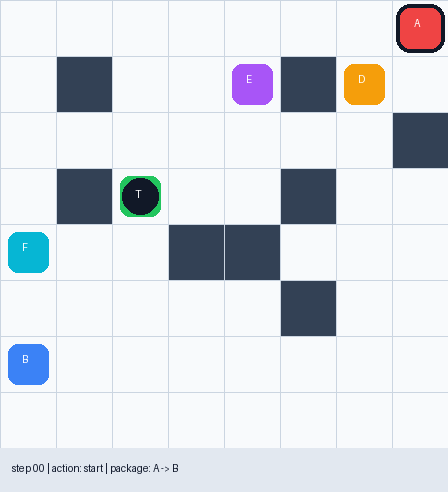

In [9]:
example = train_trajectories[0]
print("Example trajectory")
print("  layout_id:", example["layout_id"])
print("  episode_seed:", example["episode_seed"])
print("  num_steps:", example["num_steps"])

obs0 = example["observations"][0]
print("\nObservation")
print("  grid shape:", obs0["grid"].shape)
print("  vector shape:", obs0["vector"].shape)

simulator = DeliverySimulator8x8()
simulator.reset(example["scenario"])
print("\nInitial frame")
print(simulator.render())

print("\nAnimated example")
show_episode_gif(example["scenario"], example["actions"], path="expert_demo.gif")


In [13]:

def add_target_channel(obs):
    """
    Adds a 7th channel to the grid.
    The new channel marks the current target cell:
    - before pickup: package location
    - after pickup: destination location
    """

    grid = obs["grid"].astype(np.float32)  # shape: (6, 8, 8)
    vector = obs["vector"].astype(np.float32)

    # In the notebook vector:
    # vector[5] = target_row normalized
    # vector[6] = target_col normalized
    target_row = int(round(vector[5] * (GRID_SIZE - 1)))
    target_col = int(round(vector[6] * (GRID_SIZE - 1)))

    target_channel = np.zeros((1, GRID_SIZE, GRID_SIZE), dtype=np.float32)
    target_channel[0, target_row, target_col] = 1.0

    enhanced_grid = np.concatenate([grid, target_channel], axis=0)

    return enhanced_grid

In [14]:
modular_train_dataset = ModularNavigationDataset(
    train_trajectories
)

modular_train_loader = DataLoader(
    modular_train_dataset,
    batch_size=128,
    shuffle=True
)

grid_example, vector_example, previous_example, mask_example, y_example = (
    modular_train_dataset[0]
)

print("Samples:", len(modular_train_dataset))
print("Grid shape:", grid_example.shape)
print("Vector shape:", vector_example.shape)
print("Previous action:", int(previous_example))
print("Target action:", int(y_example))

Samples: 5327
Grid shape: torch.Size([7, 8, 8])
Vector shape: torch.Size([13])
Previous action: 6
Target action: 1


In [15]:
def flatten_observation(obs):
    """Flatten one observation into a feature vector."""
    return np.concatenate([
        obs["grid"].astype(np.float32).reshape(-1),
        obs["vector"].astype(np.float32),
    ])


class CNNActionDataset(torch.utils.data.Dataset):
    def __init__(self, trajectories):
        self.samples = [
            (obs, int(action))
            for trajectory in trajectories
            for obs, action in zip(
                trajectory["observations"],
                trajectory["actions"],
                strict=True
            )
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        obs, action = self.samples[idx]

        grid = torch.tensor(add_target_channel(obs), dtype=torch.float32)
        vector = torch.tensor(obs["vector"], dtype=torch.float32)
        mask = torch.tensor(obs["action_mask"], dtype=torch.bool)
        y = torch.tensor(action, dtype=torch.long)

        return grid, vector, mask, y


train_dataset = CNNActionDataset(train_trajectories)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

grid0, vector0, mask0, y0 = train_dataset[0]
action_counts = Counter(int(train_dataset[i][3]) for i in range(len(train_dataset)))
print("Created dataset")
print("  state-action samples:", len(train_dataset))
print("  vector dimension:", vector0.numel())
print("  first action:", int(y0), ACTION_NAMES[int(y0)])
print("  action counts:", {ACTION_NAMES[k]: v for k, v in action_counts.items()})

Created dataset
  state-action samples: 5327
  vector dimension: 13
  first action: 1 north
  action counts: {'north': 1148, 'east': 1120, 'pickup': 400, 'south': 1066, 'west': 1193, 'dropoff': 400}


In [17]:
class ModularNavigationModel(nn.Module):
    """
    Primer módulo:
        CNN que analiza espacialmente la cuadrícula.

    Segundo módulo:
        Cabeza de decisión que combina:
        - característica de la posición del robot
        - característica del objetivo
        - características de las cuatro celdas vecinas
        - resumen global del tablero
        - vector numérico
        - acción anterior
    """

    def __init__(
        self,
        vector_dim=13,
        num_actions=6,
        previous_action_vocab=7
    ):
        super().__init__()

        # No se aplana el mapa aquí.
        self.spatial_encoder = nn.Sequential(
            nn.Conv2d(
                7,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(
                64,
                96,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )

        # Procesamiento de las 13 características globales.
        self.vector_encoder = nn.Sequential(
            nn.Linear(vector_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 64),
            nn.ReLU()
        )

        # Representación aprendida de la acción anterior.
        self.previous_action_embedding = nn.Embedding(
            previous_action_vocab,
            16
        )

        # Se extraen siete grupos espaciales:
        # robot + objetivo + cuatro vecinos + resumen global.
        spatial_decision_dim = 96 * 7

        decision_input_dim = (
            spatial_decision_dim
            + 64   # vector
            + 16   # acción anterior
        )

        self.decision_head = nn.Sequential(
            nn.Linear(decision_input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(128, num_actions)
        )

    @staticmethod
    def gather_position_features(
        feature_map,
        rows,
        columns
    ):
        """
        Extrae el vector de características de una posición
        para cada elemento del batch.
        """
        batch_indices = torch.arange(
            feature_map.size(0),
            device=feature_map.device
        )

        return feature_map[
            batch_indices,
            :,
            rows,
            columns
        ]

    def forward(
        self,
        grid,
        vector,
        previous_action
    ):
        """
        grid:
            [batch, 7, 8, 8]

        vector:
            [batch, 13]

        previous_action:
            [batch]
        """

        feature_map = self.spatial_encoder(grid)

        height = feature_map.size(2)
        width = feature_map.size(3)

        # Posición del robot:
        # vector[0] = row normalizada
        # vector[1] = col normalizada
        robot_rows = torch.round(
            vector[:, 0] * (height - 1)
        ).long()

        robot_columns = torch.round(
            vector[:, 1] * (width - 1)
        ).long()

        robot_rows = robot_rows.clamp(
            min=0,
            max=height - 1
        )

        robot_columns = robot_columns.clamp(
            min=0,
            max=width - 1
        )

        # Posición del objetivo:
        # vector[5] = target row normalizada
        # vector[6] = target col normalizada
        target_rows = torch.round(
            vector[:, 5] * (height - 1)
        ).long()

        target_columns = torch.round(
            vector[:, 6] * (width - 1)
        ).long()

        target_rows = target_rows.clamp(
            min=0,
            max=height - 1
        )

        target_columns = target_columns.clamp(
            min=0,
            max=width - 1
        )

        # Características exactamente donde está el robot.
        robot_features = self.gather_position_features(
            feature_map,
            robot_rows,
            robot_columns
        )

        # Características exactamente donde está el objetivo.
        target_features = self.gather_position_features(
            feature_map,
            target_rows,
            target_columns
        )

        # Extraer las cuatro celdas vecinas en el mismo orden
        # de ACTION_DELTAS:
        # south, north, east, west.
        neighbor_features = []

        for action_id in range(4):
            dr, dc = ACTION_DELTAS[action_id]

            neighbor_rows = robot_rows + dr
            neighbor_columns = robot_columns + dc

            valid_position = (
                (neighbor_rows >= 0)
                & (neighbor_rows < height)
                & (neighbor_columns >= 0)
                & (neighbor_columns < width)
            )

            safe_rows = neighbor_rows.clamp(
                min=0,
                max=height - 1
            )

            safe_columns = neighbor_columns.clamp(
                min=0,
                max=width - 1
            )

            current_neighbor_features = (
                self.gather_position_features(
                    feature_map,
                    safe_rows,
                    safe_columns
                )
            )

            # Una posición fuera del tablero se representa con ceros.
            current_neighbor_features = (
                current_neighbor_features
                * valid_position.unsqueeze(1).to(
                    feature_map.dtype
                )
            )

            neighbor_features.append(
                current_neighbor_features
            )

        neighbor_features = torch.cat(
            neighbor_features,
            dim=1
        )

        # Resumen global aprendido del mapa.
        global_features = feature_map.mean(
            dim=(2, 3)
        )

        vector_features = self.vector_encoder(
            vector
        )

        previous_action_features = (
            self.previous_action_embedding(
                previous_action
            )
        )

        decision_features = torch.cat(
            [
                robot_features,
                target_features,
                neighbor_features,
                global_features,
                vector_features,
                previous_action_features
            ],
            dim=1
        )

        return self.decision_head(
            decision_features
        )

In [18]:
class CNNActionModel(nn.Module):
    def __init__(self, vector_dim=13, num_actions=6):
        super().__init__()

        self.grid_net = nn.Sequential(
            nn.Conv2d(7, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),

            nn.Flatten()
        )

        grid_feature_dim = 96 * 8 * 8

        self.vector_net = nn.Sequential(
            nn.Linear(vector_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(grid_feature_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_actions)
        )

    def forward(self, grid, vector):
        grid_features = self.grid_net(grid)
        vector_features = self.vector_net(vector)
        features = torch.cat([grid_features, vector_features], dim=1)
        return self.head(features)

from collections import Counter

# Como ahora el dataset devuelve (x, mask, y), la acción está en índice 2
action_counts = Counter(int(train_dataset[i][3]) for i in range(len(train_dataset)))

print("Action counts:", action_counts)

num_actions = 6
counts = torch.zeros(num_actions, dtype=torch.float32)

for action_id, count in action_counts.items():
    counts[action_id] = count

class_weights = counts.sum() / (num_actions * counts.clamp(min=1))
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(DEVICE)

print("Class weights:", class_weights)


model = CNNActionModel(vector_dim=vector0.numel()).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

Action counts: Counter({3: 1193, 1: 1148, 2: 1120, 0: 1066, 4: 400, 5: 400})
Class weights: tensor([0.6591, 0.6120, 0.6273, 0.5889, 1.7564, 1.7564], device='cuda:0')
CNNActionModel(
  (grid_net): Sequential(
    (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (vector_net): Sequenti

In [19]:
modular_model = ModularNavigationModel(
    vector_dim=vector_example.numel(),
    num_actions=6
).to(DEVICE)

print(modular_model)

total_parameters = sum(
    parameter.numel()
    for parameter in modular_model.parameters()
)

print("Parameters:", total_parameters)

ModularNavigationModel(
  (spatial_encoder): Sequential(
    (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (vector_encoder): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): R

In [20]:
@torch.no_grad()
def train_action_accuracy():
    model.eval()
    correct = 0
    total = 0

    for grid, vector, mask, y in DataLoader(train_dataset, batch_size=1024):
        grid = grid.to(DEVICE)
        vector = vector.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(grid, vector)
        logits = logits.masked_fill(~mask, -1e9)

        pred = logits.argmax(dim=1)

        correct += int((pred == y).sum().item())
        total += y.size(0)

    return correct / total


EPOCHS = 30
for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    total_loss = total_examples = 0

    for grid, vector, mask, y in train_loader:
        grid = grid.to(DEVICE)
        vector = vector.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(grid, vector)
        logits = logits.masked_fill(~mask, -1e9)

        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
    

    print(f"epoch {epoch:02d} | loss {total_loss / total_examples:.4f}")

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | loss {total_loss / total_examples:.4f} | train action acc {train_action_accuracy():.3f}")

  0%|          | 0/30 [00:00<?, ?it/s]

epoch 01 | loss 0.6948
epoch 01 | loss 0.6948 | train action acc 0.762
epoch 02 | loss 0.3923
epoch 03 | loss 0.2379
epoch 04 | loss 0.1638
epoch 05 | loss 0.1178
epoch 05 | loss 0.1178 | train action acc 0.946
epoch 06 | loss 0.0998
epoch 07 | loss 0.0830
epoch 08 | loss 0.0786
epoch 09 | loss 0.0501
epoch 10 | loss 0.0439
epoch 10 | loss 0.0439 | train action acc 0.987
epoch 11 | loss 0.0377
epoch 12 | loss 0.0310
epoch 13 | loss 0.0266
epoch 14 | loss 0.0189
epoch 15 | loss 0.0186
epoch 15 | loss 0.0186 | train action acc 0.994
epoch 16 | loss 0.0118
epoch 17 | loss 0.0147
epoch 18 | loss 0.0154
epoch 19 | loss 0.0217
epoch 20 | loss 0.0293
epoch 20 | loss 0.0293 | train action acc 0.992
epoch 21 | loss 0.0240
epoch 22 | loss 0.0066
epoch 23 | loss 0.0093
epoch 24 | loss 0.0117
epoch 25 | loss 0.0178
epoch 25 | loss 0.0178 | train action acc 0.997
epoch 26 | loss 0.0103
epoch 27 | loss 0.0073
epoch 28 | loss 0.0038
epoch 29 | loss 0.0023
epoch 30 | loss 0.0050
epoch 30 | loss 0.0050

In [22]:
@torch.no_grad()
def model_action(obs):
    model.eval()

    grid = torch.tensor(
        add_target_channel(obs),
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    vector = torch.tensor(
        obs["vector"],
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    mask = torch.tensor(
        obs["action_mask"],
        dtype=torch.bool,
        device=DEVICE
    )

    logits = model(grid, vector).squeeze(0)
    logits = logits.masked_fill(~mask, -1e9)

    return int(logits.argmax().item())


def run_episode(scenario, action_fn, max_steps=MAX_STEPS, render=False):
    """Run an action model on one scenario."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames, actions = [], []
    invalid_pickup_or_dropoff = 0
    done = False

    if render:
        frames.append(simulator.render())

    for _ in range(max_steps):
        action = int(action_fn(simulator.observation()))
        _, done, timed_out, info = simulator.step(action)
        actions.append(action)
        invalid_pickup_or_dropoff += int(info["invalid_pickup_or_dropoff"])
        if render:
            frames.append(simulator.render())
        if done or timed_out:
            break

    return {
        "success": done,
        "steps": len(actions),
        "invalid_pickup_or_dropoff": invalid_pickup_or_dropoff,
        "actions": actions,
        "frames": frames,
    }


def evaluate_action_model(scenarios, action_fn, limit=None):
    """Evaluate complete-episode success on a scenario list."""
    results = [run_episode(s, action_fn) for s in tqdm(scenarios[:limit])]
    return {
        "success_rate": float(np.mean([r["success"] for r in results])),
        "avg_steps": float(np.mean([r["steps"] for r in results])),
        "avg_invalid_pickup_or_dropoff": float(np.mean([r["invalid_pickup_or_dropoff"] for r in results])),
        "results": results,
    }


rng = np.random.default_rng(SEED)


def random_action_model(obs):
    """Sample a random action."""
    return int(rng.integers(6))


def cnn_action_model(obs):
    return model_action(obs)

In [23]:
@torch.no_grad()
def model_action_with_mask(obs, action_mask):
    """Choose the highest-logit action using a custom valid-action mask."""
    model.eval()

    grid = torch.tensor(
        add_target_channel(obs),
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    vector = torch.tensor(
        obs["vector"],
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    mask = torch.tensor(
        action_mask,
        dtype=torch.bool,
        device=DEVICE
    )

    logits = model(grid, vector).squeeze(0)
    logits = logits.masked_fill(~mask, -1e9)

    return int(logits.argmax().item())


def run_episode_no_backtrack(scenario, max_steps=MAX_STEPS):
    """
    Run the CNN, but avoid an immediate return to the previous cell
    when at least one other valid action exists.
    """
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)

    previous_position = None
    actions = []
    interventions = 0
    done = False

    for _ in range(max_steps):
        obs = simulator.observation()
        original_mask = obs["action_mask"].copy()

        # Original action selected by the CNN.
        action = model_action(obs)

        # Only movement actions can return to the previous position.
        if previous_position is not None and action in ACTION_DELTAS:
            row, col = simulator.agent_pos
            dr, dc = ACTION_DELTAS[action]
            next_position = (row + dr, col + dc)

            if next_position == previous_position:
                alternative_mask = original_mask.copy()

                # Temporarily forbid only the immediate reversal.
                alternative_mask[action] = False

                # Do not forbid it in a dead end.
                if alternative_mask.any():
                    action = model_action_with_mask(obs, alternative_mask)
                    interventions += 1

        position_before_action = simulator.agent_pos
        _, done, timed_out, _ = simulator.step(action)
        actions.append(action)

        # Update the previous cell only after a real movement.
        if (
            action in ACTION_DELTAS
            and simulator.agent_pos != position_before_action
        ):
            previous_position = position_before_action

        if done or timed_out:
            break

    return {
        "success": done,
        "steps": len(actions),
        "actions": actions,
        "interventions": interventions,
    }


def evaluate_no_backtrack(scenarios):
    results = [
        run_episode_no_backtrack(scenario)
        for scenario in tqdm(scenarios, desc="Evaluating no-backtrack")
    ]

    return {
        "success_rate": float(np.mean([
            result["success"] for result in results
        ])),
        "avg_steps": float(np.mean([
            result["steps"] for result in results
        ])),
        "avg_interventions": float(np.mean([
            result["interventions"] for result in results
        ])),
        "results": results,
    }

In [24]:
modular_action_counts = Counter(
    sample["action"]
    for sample in modular_train_dataset.samples
)

modular_counts = torch.zeros(
    6,
    dtype=torch.float32
)

for action_id, count in modular_action_counts.items():
    modular_counts[action_id] = count

modular_class_weights = (
    modular_counts.sum()
    / (
        6
        * modular_counts.clamp(min=1)
    )
)

modular_class_weights = (
    modular_class_weights
    / modular_class_weights.mean()
)

modular_class_weights = modular_class_weights.to(
    DEVICE
)

print("Action counts:", modular_action_counts)
print("Class weights:", modular_class_weights)

Action counts: Counter({3: 1193, 1: 1148, 2: 1120, 0: 1066, 4: 400, 5: 400})
Class weights: tensor([0.6591, 0.6120, 0.6273, 0.5889, 1.7564, 1.7564], device='cuda:0')


In [26]:
modular_optimizer = torch.optim.AdamW(
    modular_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

modular_criterion = nn.CrossEntropyLoss(
    weight=modular_class_weights
)

In [28]:
@torch.no_grad()
def modular_train_accuracy():
    modular_model.eval()

    correct = 0
    total = 0

    accuracy_loader = DataLoader(
        modular_train_dataset,
        batch_size=1024,
        shuffle=False
    )

    for (
        grid,
        vector,
        previous_action,
        mask,
        y
    ) in accuracy_loader:

        grid = grid.to(DEVICE)
        vector = vector.to(DEVICE)
        previous_action = previous_action.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        logits = modular_model(
            grid,
            vector,
            previous_action
        )

        logits = logits.masked_fill(
            ~mask,
            -1e9
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += int(
            (predictions == y).sum().item()
        )

        total += y.size(0)

    return correct / total

In [29]:
MODULAR_EPOCHS = 30

for epoch in tqdm(
    range(1, MODULAR_EPOCHS + 1)
):
    modular_model.train()

    total_loss = 0.0
    total_examples = 0

    for (
        grid,
        vector,
        previous_action,
        mask,
        y
    ) in modular_train_loader:

        grid = grid.to(DEVICE)
        vector = vector.to(DEVICE)
        previous_action = previous_action.to(DEVICE)
        mask = mask.to(DEVICE)
        y = y.to(DEVICE)

        logits = modular_model(
            grid,
            vector,
            previous_action
        )

        logits = logits.masked_fill(
            ~mask,
            -1e9
        )

        loss = modular_criterion(
            logits,
            y
        )

        modular_optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            modular_model.parameters(),
            max_norm=5.0
        )

        modular_optimizer.step()

        batch_size = y.size(0)

        total_loss += (
            float(loss.item())
            * batch_size
        )

        total_examples += batch_size

    average_loss = (
        total_loss
        / total_examples
    )

    if (
        epoch == 1
        or epoch % 5 == 0
        or epoch == MODULAR_EPOCHS
    ):
        train_accuracy = modular_train_accuracy()

        print(
            f"epoch {epoch:02d} | "
            f"loss {average_loss:.4f} | "
            f"train action acc {train_accuracy:.3f}"
        )

  0%|          | 0/30 [00:00<?, ?it/s]

epoch 01 | loss 0.4008 | train action acc 0.939
epoch 05 | loss 0.0298 | train action acc 0.995
epoch 10 | loss 0.0134 | train action acc 0.986
epoch 15 | loss 0.0009 | train action acc 1.000
epoch 20 | loss 0.0003 | train action acc 1.000
epoch 25 | loss 0.0028 | train action acc 1.000
epoch 30 | loss 0.0066 | train action acc 0.999


In [31]:
@torch.no_grad()
def modular_model_action(
    obs,
    previous_action
):
    modular_model.eval()

    grid = torch.tensor(
        add_target_channel(obs),
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    vector = torch.tensor(
        obs["vector"],
        dtype=torch.float32,
        device=DEVICE
    ).unsqueeze(0)

    previous_action_tensor = torch.tensor(
        [previous_action],
        dtype=torch.long,
        device=DEVICE
    )

    mask = torch.tensor(
        obs["action_mask"],
        dtype=torch.bool,
        device=DEVICE
    )

    logits = modular_model(
        grid,
        vector,
        previous_action_tensor
    ).squeeze(0)

    logits = logits.masked_fill(
        ~mask,
        -1e9
    )

    return int(
        logits.argmax().item()
    )
def run_episode_modular(
    scenario,
    max_steps=MAX_STEPS,
    render=False
):
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)

    previous_action = START_ACTION

    frames = []
    actions = []

    invalid_pickup_or_dropoff = 0
    done = False

    if render:
        frames.append(
            simulator.render()
        )

    for _ in range(max_steps):
        obs = simulator.observation()

        action = modular_model_action(
            obs,
            previous_action
        )

        _, done, timed_out, info = (
            simulator.step(action)
        )

        actions.append(action)

        invalid_pickup_or_dropoff += int(
            info["invalid_pickup_or_dropoff"]
        )

        previous_action = action

        if render:
            frames.append(
                simulator.render()
            )

        if done or timed_out:
            break

    return {
        "success": done,
        "steps": len(actions),
        "actions": actions,
        "frames": frames,
        "invalid_pickup_or_dropoff": (
            invalid_pickup_or_dropoff
        ),
    }
def evaluate_modular_model(scenarios):
    results = [
        run_episode_modular(scenario)
        for scenario in tqdm(
            scenarios,
            desc="Evaluating modular navigation model"
        )
    ]

    return {
        "success_rate": float(
            np.mean([
                result["success"]
                for result in results
            ])
        ),
        "avg_steps": float(
            np.mean([
                result["steps"]
                for result in results
            ])
        ),
        "avg_invalid_pickup_or_dropoff": float(
            np.mean([
                result["invalid_pickup_or_dropoff"]
                for result in results
            ])
        ),
        "results": results,
    }

In [32]:
EVAL_LIMIT = None

random_eval = evaluate_action_model(valid_scenarios, random_action_model, limit=EVAL_LIMIT)
cnn_eval = evaluate_action_model(valid_scenarios, cnn_action_model, limit=EVAL_LIMIT)

for name, metrics in [("random", random_eval), ("CNN", cnn_eval)]:
    print(name, {k: v for k, v in metrics.items() if k != "results"})


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

random {'success_rate': 0.035, 'avg_steps': 119.035, 'avg_invalid_pickup_or_dropoff': 39.055}
CNN {'success_rate': 0.76, 'avg_steps': 38.315, 'avg_invalid_pickup_or_dropoff': 0.0}


In [33]:
modular_eval = evaluate_modular_model(
    valid_scenarios
)

print(
    "Original CNN:",
    cnn_eval["success_rate"]
)

print(
    "Modular model:",
    modular_eval["success_rate"]
)

print(
    "Average steps:",
    modular_eval["avg_steps"]
)

print(
    "Invalid pickup/dropoff:",
    modular_eval[
        "avg_invalid_pickup_or_dropoff"
    ]
)

Evaluating modular navigation model:   0%|          | 0/200 [00:00<?, ?it/s]

Original CNN: 0.76
Modular model: 0.87
Average steps: 27.09
Invalid pickup/dropoff: 0.0


In [35]:
baseline_results = cnn_eval["results"]
modular_results = modular_eval["results"]

rescued = sum(
    not old["success"]
    and new["success"]
    for old, new in zip(
        baseline_results,
        modular_results
    )
)

harmed = sum(
    old["success"]
    and not new["success"]
    for old, new in zip(
        baseline_results,
        modular_results
    )
)

successful_in_both = sum(
    old["success"]
    and new["success"]
    for old, new in zip(
        baseline_results,
        modular_results
    )
)

print("Failed episodes rescued:", rescued)
print("Successful episodes harmed:", harmed)
print("Successful in both:", successful_in_both)
print("Net episodes gained:", rescued - harmed)

Failed episodes rescued: 29
Successful episodes harmed: 7
Successful in both: 145
Net episodes gained: 22


In [36]:
no_backtrack_eval = evaluate_no_backtrack(valid_scenarios)

baseline_results = cnn_eval["results"]
modified_results = no_backtrack_eval["results"]

rescued = sum(
    not old["success"] and new["success"]
    for old, new in zip(baseline_results, modified_results)
)

harmed = sum(
    old["success"] and not new["success"]
    for old, new in zip(baseline_results, modified_results)
)

unchanged_success = sum(
    old["success"] and new["success"]
    for old, new in zip(baseline_results, modified_results)
)

print("Baseline success rate:", cnn_eval["success_rate"])
print("No-backtrack success rate:", no_backtrack_eval["success_rate"])
print("Average interventions:", no_backtrack_eval["avg_interventions"])
print("Failed episodes rescued:", rescued)
print("Successful episodes harmed:", harmed)
print("Successful in both:", unchanged_success)
print("Net episodes gained:", rescued - harmed)

Evaluating no-backtrack:   0%|          | 0/200 [00:00<?, ?it/s]

Baseline success rate: 0.76
No-backtrack success rate: 0.945
Average interventions: 4.265
Failed episodes rescued: 38
Successful episodes harmed: 1
Successful in both: 151
Net episodes gained: 37


In [37]:
def classify_failure(scenario, actions):
    sim = DeliverySimulator8x8()
    sim.reset(scenario)

    picked_up = False
    near_wall_mistakes = 0
    invalid_pick_drop = 0

    for action in actions:
        obs = sim.observation()
        mask = obs["action_mask"]

        if action in [0, 1, 2, 3] and not mask[action]:
            near_wall_mistakes += 1

        _, done, timed_out, info = sim.step(action)

        if info["invalid_pickup_or_dropoff"]:
            invalid_pick_drop += 1

        if sim.carrying:
            picked_up = True

        if done:
            return "success"

    if invalid_pick_drop > 0:
        return "invalid_pickup_dropoff"
    if near_wall_mistakes > 0:
        return "wall_or_invalid_move"
    if not picked_up:
        return "before_pickup"
    return "after_pickup"


failure_counts = Counter()

for scenario, result in zip(valid_scenarios, cnn_eval["results"]):
    category = classify_failure(scenario, result["actions"])
    failure_counts[category] += 1

failure_counts

Counter({'success': 152, 'after_pickup': 23, 'before_pickup': 25})

In [ ]:

example_run = run_episode(valid_scenarios[0], cnn_action_model, render=True)
print("success:", example_run["success"])
print("steps:", example_run["steps"])
print("invalid pickup/dropoff:", example_run["invalid_pickup_or_dropoff"])
print("actions:", [ACTION_NAMES[a] for a in example_run["actions"]])
print("initial frame:")
print(example_run["frames"][0])
print("final frame:")
print(example_run["frames"][-1])

print("animated rollout:")
show_episode_gif(valid_scenarios[0], example_run["actions"], path="model_rollout.gif")


In [ ]:
def generate_predictions(scenarios, action_fn, limit=None):
    """Generate action sequences for scenarios."""
    predictions = []
    for scenario in tqdm(scenarios[:limit], desc="Generating predictions"):
        episode = run_episode(scenario, action_fn)
        predictions.append({
            "layout_id": scenario["layout_id"],
            "episode_seed": scenario["episode_seed"],
            "actions": episode["actions"],
        })
    return predictions


def save_predictions_zip(predictions, path="predictions.zip"):
    """Write predictions.jsonl into a zip file."""
    jsonl_path = Path("predictions.jsonl")
    with jsonl_path.open("w", encoding="utf-8") as f:
        for pred in predictions:
            f.write(json.dumps(pred) + "\n")
    with zipfile.ZipFile(path, "w") as zf:
        zf.write(jsonl_path, "predictions.jsonl")
    print(f"Saved {path}")


# For a real submission, use limit=None.
test_predictions_preview = generate_predictions(test_scenarios, cnn_action_model, limit=5)
test_predictions_preview[0]

In [ ]:
#test_predictions = generate_predictions(test_scenarios, cnn_action_model, limit=3)

#print(type(test_predictions))
#print(test_predictions)

In [ ]:
import pandas as pd
import numpy as np
import os

# Generar todas las predicciones
test_predictions = generate_predictions(test_scenarios, cnn_action_model, limit=None)

# Convertir a DataFrame según el formato
if isinstance(test_predictions, pd.DataFrame):
    submission = test_predictions.copy()

elif isinstance(test_predictions, list):
    # Si es lista de diccionarios, por ejemplo:
    # [{"scenario_id": ..., "action": ...}, ...]
    if len(test_predictions) > 0 and isinstance(test_predictions[0], dict):
        submission = pd.DataFrame(test_predictions)

    # Si es lista simple, por ejemplo:
    # [0, 1, 2, 0, ...]
    else:
        submission = pd.DataFrame({
            "id": range(len(test_predictions)),
            "prediction": test_predictions
        })

elif isinstance(test_predictions, dict):
    # Si es diccionario, por ejemplo:
    # {"scenario_1": pred, "scenario_2": pred}
    submission = pd.DataFrame(
        list(test_predictions.items()),
        columns=["id", "prediction"]
    )

else:
    arr = np.array(test_predictions)
    submission = pd.DataFrame({
        "id": range(len(arr)),
        "prediction": arr
    })

# Guardar con el nombre exacto que Kaggle pide
submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Saved submission.csv:", submission.shape)
print(submission.head())
print(os.listdir("/kaggle/working"))

Idea/ver el input, si es acorde al modelo